<a href="https://colab.research.google.com/github/seventeeenm/probabilidad/blob/main/Unidad1/Practica_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Probabilidad y Estadistica<hr>
##Unidad 1
##Practica 6: Estadística descriptiva del Dataset Autos
Docente: Dr. Jose Gabriel Rodriguez Rivas<br>
Alumno: Dilan Yahir Escareño Duran

1. **Cargar el Dataset de Autos y realizar las Estadísticas descriptivas básicas y medidas de tendencia central**

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import *
import random
import numpy as np

#CARGAMOS EL DATASET
df = pd.read_csv('autos2.csv')
#esto es para asegurarnos de que el precio sea numérico y quitar valores nulos si los hay
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])
precios = df['price'].tolist()
#Convertimos la columna de precios a una lista de Python normal
print("Dataset cargado. Total de datos limpios:", len(precios))

# Medidas de tendencia central
min_precio = min(precios)
max_precio = max(precios)
moda_precio = mode(precios)
media_precio = mean(precios)
mediana_precio = median(precios)
std_precio = stdev(precios)
print("--- Estadísticas Básicas ---")
print(f"Valor mínimo: ${min_precio}")
print(f"Valor máximo: ${max_precio}")
print(f"Moda: ${moda_precio}")
print(f"Media: ${media_precio:.2f}")
print(f"Mediana: ${mediana_precio}")
print(f"Desviación Estándar: ${std_precio:.2f}")

print("\n--- Estadísticos y Cuartiles con describe() ---")
print(df['price'].describe())

Dataset cargado. Total de datos limpios: 201
--- Estadísticas Básicas ---
Valor mínimo: $5118.0
Valor máximo: $45400.0
Moda: $16500.0
Media: $13207.13
Mediana: $10295.0
Desviación Estándar: $7947.07

--- Estadísticos y Cuartiles con describe() ---
count      201.000000
mean     13207.129353
std       7947.066342
min       5118.000000
25%       7775.000000
50%      10295.000000
75%      16500.000000
max      45400.000000
Name: price, dtype: float64


2. **Realizar un Histograma de precios de los automóviles**

Cantidad óptima de bins (Regla de Sturges): 9


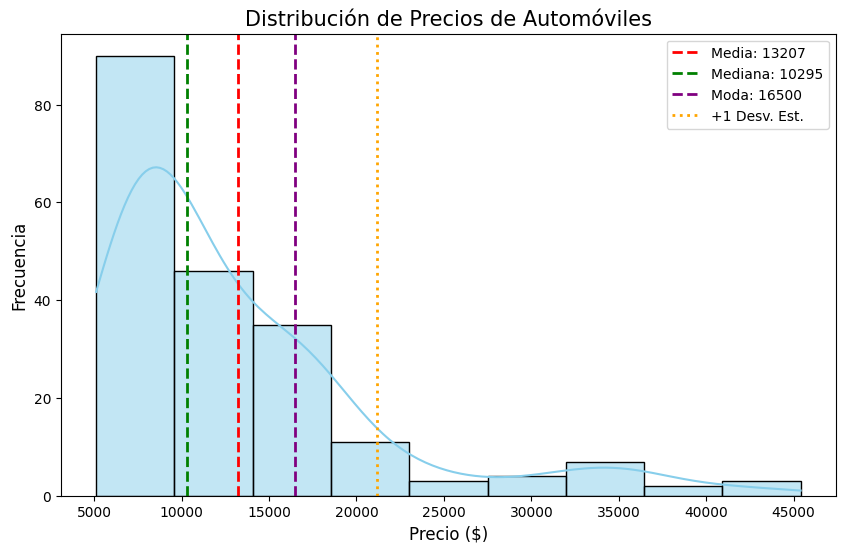

In [10]:
n = len(precios)
k = int(np.ceil(1 + np.log2(n)))
print(f"Cantidad óptima de bins (Regla de Sturges): {k}")

# Crear Histograma
plt.figure(figsize=(10, 6))
sns.histplot(precios, bins=k, kde=True, color='skyblue')
plt.axvline(media_precio, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media_precio:.0f}')
plt.axvline(mediana_precio, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_precio:.0f}')
plt.axvline(moda_precio, color='purple', linestyle='dashed', linewidth=2, label=f'Moda: {moda_precio:.0f}')
plt.axvline(media_precio + std_precio, color='orange', linestyle='dotted', linewidth=2, label='+1 Desv. Est.')
plt.title('Distribución de Precios de Automóviles', fontsize=15)
plt.xlabel('Precio ($)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()
plt.show()

**Datos y conclusiones**

Los datos muestran que el rango de precios de los autos va desde los \$5,118 hasta los \$45,400. Observamos que la media (**\$13,207.13**) es considerablemente mayor que la mediana (**\$10,295.00**), lo que indica un sesgo positivo. La desviación estándar es de **\$7,947.07**, mostrando que hay bastante dispersión en los precios.

3. Diagrama de caja: Precio vs Tipo de Vehículo (Body Style)

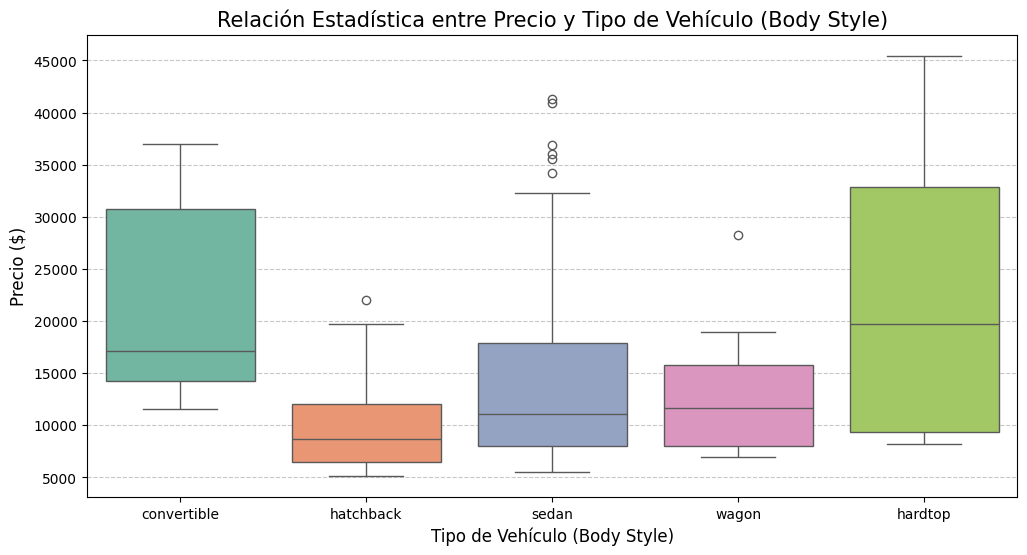

In [14]:
# Diagrama de caja y bigotes: price vs body style
plt.figure(figsize=(12, 6))
sns.boxplot(x='body-style', y='price', data=df, hue='body-style', palette='Set2', legend=False)
plt.title('Relación Estadística entre Precio y Tipo de Vehículo (Body Style)', fontsize=15)
plt.xlabel('Tipo de Vehículo (Body Style)', fontsize=12)
plt.ylabel('Precio ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Datos y conclusiones**

Los autos tipo hatchback son los más económicos y tienen el rango de dispersión más estrecho, con una media inferior a \$10,000. Por otro lado, los hardtop y convertible alcanzan los precios medios más altos (superando los \$21,000). Los vehículos sedán tienen muchísimos valores atípicos (outliers) en la parte superior, lo que indica que aunque suelen ser de precio medio, existen sedanes de hiperlujo que cuestan mucho.

4. **Diagrama de caja: Precio vs Tracción (Drive Wheels)**

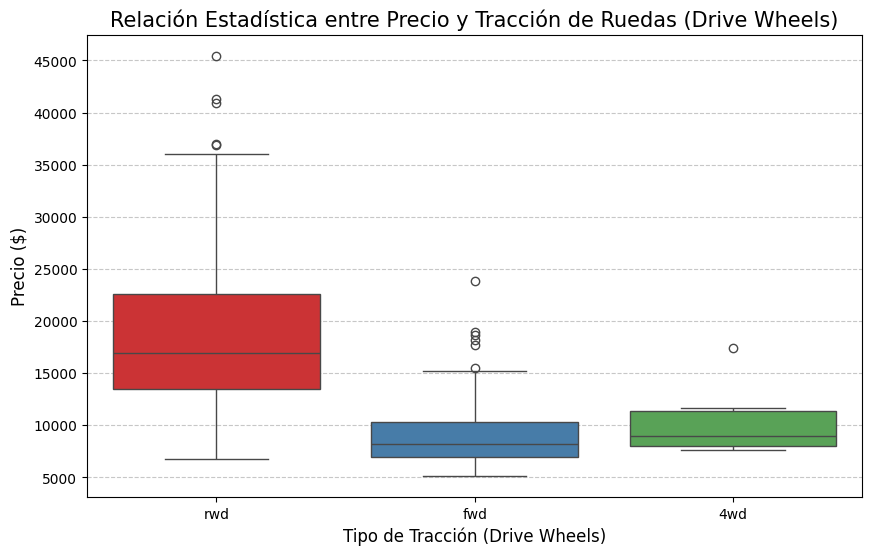

In [13]:
# Diagrama de caja y bigotes: price vs drive wheels
plt.figure(figsize=(10, 6))
sns.boxplot(x='drive-wheels', y='price', data=df, hue='drive-wheels', palette='Set1', legend=False)
plt.title('Relación Estadística entre Precio y Tracción de Ruedas (Drive Wheels)', fontsize=15)
plt.xlabel('Tipo de Tracción (Drive Wheels)', fontsize=12)
plt.ylabel('Precio ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Datos y conclusiones**

El tipo de tracción es un gran indicador del costo del auto. Los vehículos con tracción trasera (rwd) son, por mucho, los más caros, con su mediana situada cerca de los \$17,000 y alcanzando valores máximos que pasan los \$40,000. Por el contrario, la tracción delantera (fwd) se encuentra en los autos más baratos (rango inferior a \$10,000).

5. **Diagrama de caja: Precio vs Ubicación del Motor (Engine Location)**

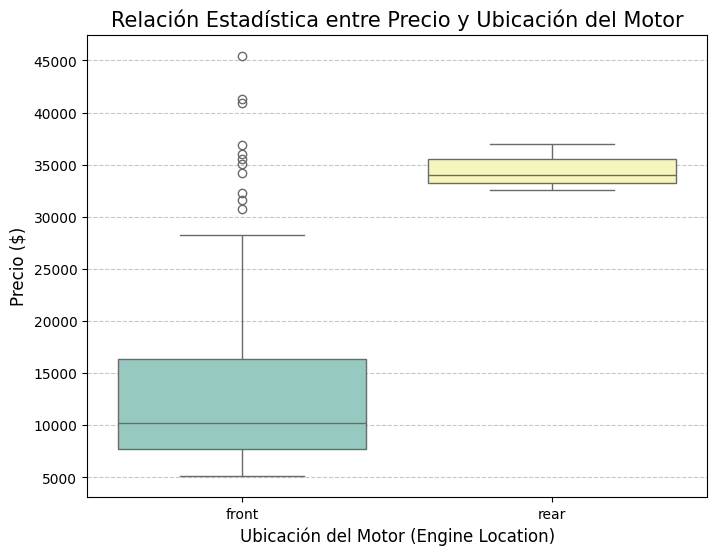

In [16]:
# Diagrama de caja y bigotes: price vs engine-location
plt.figure(figsize=(8, 6))
sns.boxplot(x='engine-location', y='price', data=df, hue='engine-location', palette='Set3', legend=False)
plt.title('Relación Estadística entre Precio y Ubicación del Motor', fontsize=15)
plt.xlabel('Ubicación del Motor (Engine Location)', fontsize=12)
plt.ylabel('Precio ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Datos y conclusiones**

Hay una abismal diferencia dependiendo de la ubicación del motor. Prácticamente todos los vehículos tienen el motor enfrente (front) con precios variados. Sin embargo, los muy pocos autos que tienen el motor en la parte trasera (rear) son exclusivamente autos carísimos/de lujo, todos por encima de los $30,000.

6. **Conclusiones generales de la práctica**

A través de la estadística descriptiva y la visualización de los datos, pudimos observar que la variable de **precios no sigue una distribución normal**. Al comparar la media, que es de aproximadamente **\$13,207**, con la mediana de **\$10,295**, podemos notar que existen algunos vehículos con precios muy elevados que hacen que el promedio aumente y no represente tan bien el precio típico de los autos.

También, mediante los diagramas de caja y bigotes, pudimos identificar algunas características que se relacionan con los vehículos de mayor precio. Por ejemplo, los autos con **tracción trasera (drive-wheels)** y **motor trasero (engine-location)** tienden a estar relacionados con vehículos de mayor costo. En cambio, los **hatchbacks con tracción delantera** se encuentran principalmente dentro del sector de precios más económicos.

Finalmente, utilizamos la **regla de Sturges** para determinar un número adecuado de intervalos en el histograma. Esto permitió visualizar mejor la distribución de los precios y confirmar que existe una mayor concentración de vehículos en los rangos de precios bajos, mientras que los vehículos de precios muy altos aparecen con mucha menor frecuencia.